MONTAGE DE GOOGLE DRIVE
Mounted at /content/drive
✓ Google Drive monté avec succès!

DBSCAN OPTIMISÉ - KD-TREE FROM SCRATCH

📂 Chargement des données depuis:
   /content/drive/MyDrive/merged_feature_final.csv

💡 Si le fichier n'est pas trouvé:
   1. Uploadez votre CSV dans Google Drive
   2. Clic droit → 'Obtenir le lien'
   3. Modifiez 'file_path' ci-dessus avec le bon chemin

✓ Données chargées en 3.09s
  Shape: 140,165 lignes × 16 colonnes

🔧 Préparation des données...
  Colonnes numériques: 16
  Normalisation (StandardScaler)...
✓ Données prêtes: (140165, 16)

🚀 Lancement de DBSCAN...

DBSCAN OPTIMISÉ AVEC KD-TREE
Paramètres: eps=0.5, min_pts=5
Nombre de points: 140,165
Nombre de features: 16

[1/3] Construction du KD-Tree...
✓ KD-Tree construit en 0.27s

[2/3] Clustering DBSCAN...
  → 5% (7,009/140,165) | 50 pts/s | ETA: 2686s
  → 10% (14,018/140,165) | 98 pts/s | ETA: 1282s
  → 15% (21,027/140,165) | 147 pts/s | ETA: 812s
  → 20% (28,036/140,165) | 29 pts/s | ETA: 3878s
  → 25% (

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement automatique lancé!

[3/3] Visualisation (5,000 points échantillonnés)...


/tmp/ipython-input-3042959425.py:251: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(data_sample[mask, 0], data_sample[mask, 1],
/tmp/ipython-input-3042959425.py:279: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✓ Visualisation sauvegardée: dbscan_optimized_results.png


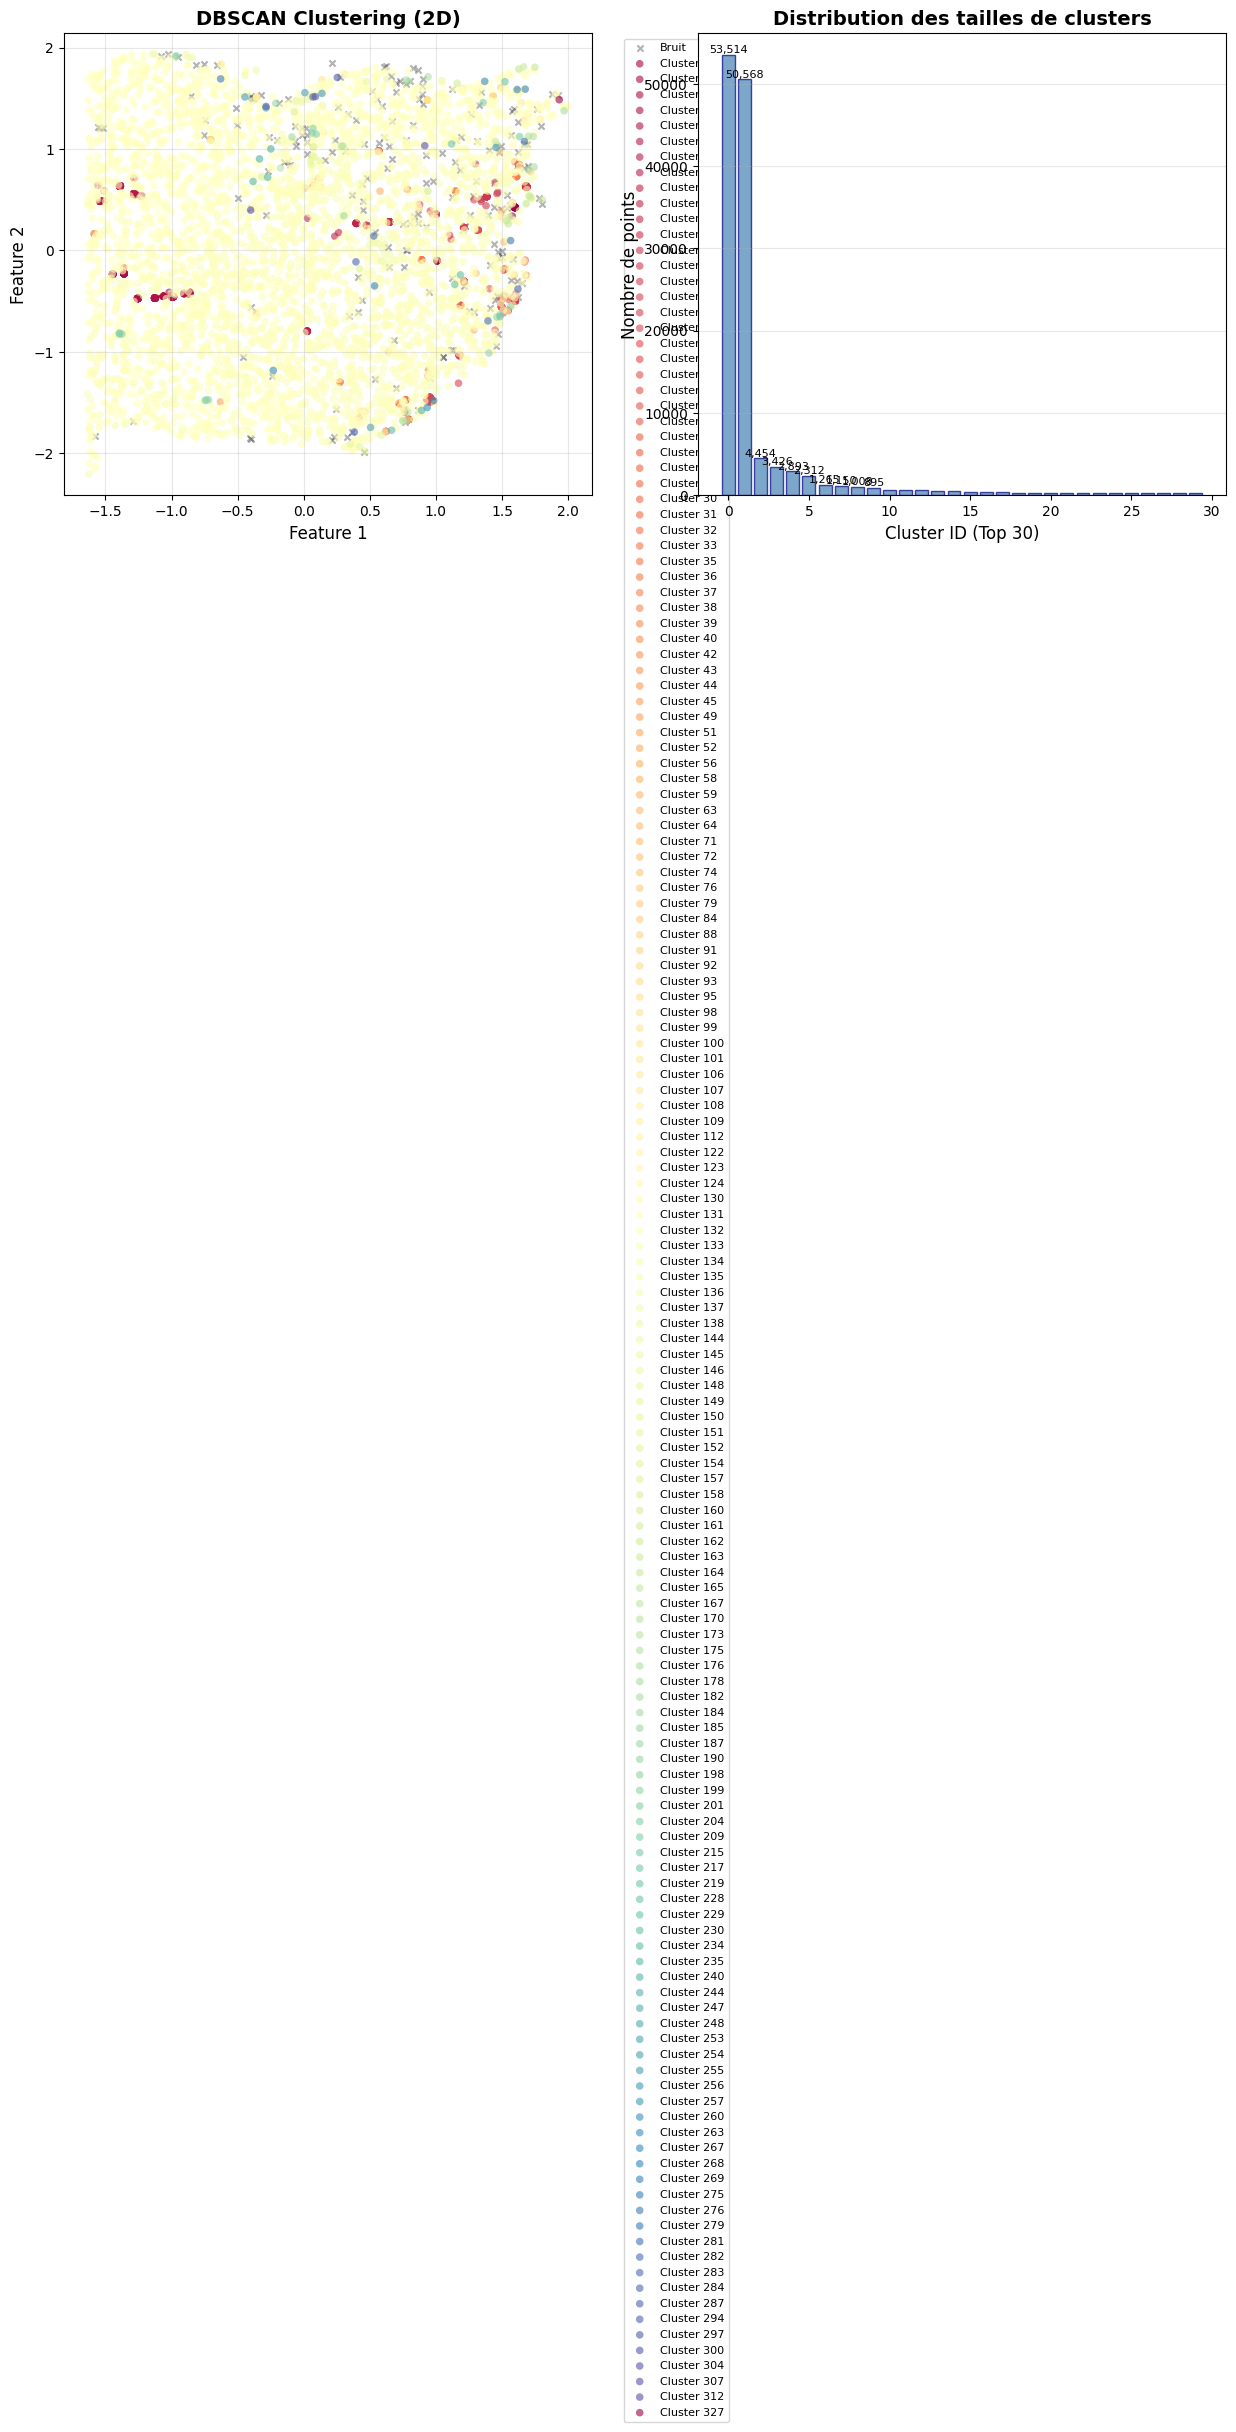


✓ TERMINÉ!


In [ ]:
# ========================================
# DBSCAN OPTIMISÉ - VERSION GOOGLE COLAB
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from collections import Counter
import time

# 🔗 MONTER GOOGLE DRIVE
print("="*60)
print("MONTAGE DE GOOGLE DRIVE")
print("="*60)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive monté avec succès!")
except:
    print("⚠️ Pas sur Google Colab, mode local activé")


class KDTree:
    """Implémentation d'un KD-Tree pour recherche de voisins efficace"""

    def __init__(self, data, leaf_size=40):
        self.data = np.asarray(data)
        self.leaf_size = leaf_size
        self.n_samples, self.n_features = self.data.shape
        self.tree = self._build_tree(np.arange(self.n_samples), depth=0)

    def _build_tree(self, indices, depth):
        n = len(indices)

        if n <= self.leaf_size:
            return {
                'is_leaf': True,
                'indices': indices,
                'data': self.data[indices]
            }

        axis = depth % self.n_features
        sorted_indices = indices[np.argsort(self.data[indices, axis])]
        median_idx = n // 2

        return {
            'is_leaf': False,
            'axis': axis,
            'median_value': self.data[sorted_indices[median_idx], axis],
            'left': self._build_tree(sorted_indices[:median_idx], depth + 1),
            'right': self._build_tree(sorted_indices[median_idx:], depth + 1)
        }

    def query_radius(self, point, radius):
        neighbors = []
        self._query_radius_recursive(self.tree, point, radius, neighbors)
        return neighbors

    def _query_radius_recursive(self, node, point, radius, neighbors):
        if node['is_leaf']:
            distances = np.sqrt(np.sum((node['data'] - point) ** 2, axis=1))
            mask = distances <= radius
            neighbors.extend(node['indices'][mask].tolist())
            return

        axis = node['axis']
        diff = point[axis] - node['median_value']

        if diff <= 0:
            self._query_radius_recursive(node['left'], point, radius, neighbors)
            if abs(diff) <= radius:
                self._query_radius_recursive(node['right'], point, radius, neighbors)
        else:
            self._query_radius_recursive(node['right'], point, radius, neighbors)
            if abs(diff) <= radius:
                self._query_radius_recursive(node['left'], point, radius, neighbors)


class DBSCANOptimized:
    """DBSCAN optimisé avec KD-Tree - Complexité O(n log n)"""

    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        self.labels_ = None
        self.kdtree = None

    def region_query(self, point_idx):
        point = self.data[point_idx]
        return self.kdtree.query_radius(point, self.eps)

    def expand_cluster(self, labels, point_idx, neighbors, cluster_id):
        labels[point_idx] = cluster_id
        seeds = set(neighbors)
        seeds.discard(point_idx)

        while seeds:
            current_point = seeds.pop()

            if labels[current_point] == -1:
                labels[current_point] = cluster_id

            if labels[current_point] != 0:
                continue

            labels[current_point] = cluster_id
            current_neighbors = self.region_query(current_point)

            if len(current_neighbors) >= self.min_pts:
                for neighbor in current_neighbors:
                    if labels[neighbor] == 0:
                        seeds.add(neighbor)

    def fit(self, data):
        self.data = np.asarray(data)
        n_points = len(self.data)i8
        labels = np.zeros(n_points, dtype=int)

        print(f"\n{'='*60}")
        print(f"DBSCAN OPTIMISÉ AVEC KD-TREE")
        print(f"{'='*60}")
        print(f"Paramètres: eps={self.eps}, min_pts={self.min_pts}")
        print(f"Nombre de points: {n_points:,}")
        print(f"Nombre de features: {self.data.shape[1]}")

        # Construction du KD-Tree
        print(f"\n[1/3] Construction du KD-Tree...")
        start_time = time.time()
        self.kdtree = KDTree(self.data, leaf_size=40)
        kdtree_time = time.time() - start_time
        print(f"✓ KD-Tree construit en {kdtree_time:.2f}s")

        # Clustering DBSCAN
        print(f"\n[2/3] Clustering DBSCAN...")
        cluster_id = 0
        start_time = time.time()
        last_print = 0

        for point_idx in range(n_points):
            progress = (point_idx / n_points) * 100
            if progress - last_print >= 5:
                elapsed = time.time() - start_time
                rate = point_idx / elapsed if elapsed > 0 else 0
                remaining = (n_points - point_idx) / rate if rate > 0 else 0
                print(f"  → {progress:.0f}% ({point_idx:,}/{n_points:,}) | "
                      f"{rate:.0f} pts/s | ETA: {remaining:.0f}s")
                last_print = progress

            if labels[point_idx] != 0:
                continue

            neighbors = self.region_query(point_idx)

            if len(neighbors) < self.min_pts:
                labels[point_idx] = -1
            else:
                cluster_id += 1
                self.expand_cluster(labels, point_idx, neighbors, cluster_id)

        clustering_time = time.time() - start_time
        print(f"✓ Clustering terminé en {clustering_time:.2f}s")

        self.labels_ = labels
        total_time = kdtree_time + clustering_time
        print(f"\n{'='*60}")
        print(f"TEMPS TOTAL: {total_time:.2f}s ({total_time/60:.2f} min)")
        print(f"{'='*60}")

        return self

    def fit_predict(self, data):
        self.fit(data)
        return self.labels_


def analyze_results(labels):
    """Analyse les résultats du clustering"""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1)

    print("\n" + "="*60)
    print("RÉSULTATS DU CLUSTERING")
    print("="*60)
    print(f"Nombre total de points: {len(labels):,}")
    print(f"Nombre de clusters: {n_clusters}")
    print(f"Nombre de points de bruit: {n_noise:,} ({n_noise/len(labels)*100:.2f}%)")

    counter = Counter(labels)
    print(f"\nDistribution des clusters (Top 20):")

    sorted_clusters = sorted([(label, count) for label, count in counter.items() if label != -1],
                            key=lambda x: x[1], reverse=True)

    for i, (label, count) in enumerate(sorted_clusters[:20], 1):
        print(f"  {i:2d}. Cluster {label}: {count:,} points ({count/len(labels)*100:.2f}%)")

    if -1 in counter:
        print(f"\n  Bruit: {counter[-1]:,} points ({counter[-1]/len(labels)*100:.2f}%)")

    if len(sorted_clusters) > 20:
        print(f"\n  ... et {len(sorted_clusters) - 20} autres clusters")

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'cluster_sizes': counter
    }


def visualize_results(data, labels, max_points=5000):
    """Visualise les résultats du clustering"""
    if len(data) > max_points:
        np.random.seed(42)
        indices = np.random.choice(len(data), max_points, replace=False)
        data_sample = data[indices]
        labels_sample = labels[indices]
        print(f"\n[3/3] Visualisation ({max_points:,} points échantillonnés)...")
    else:
        data_sample = data
        labels_sample = labels
        print(f"\n[3/3] Visualisation...")

    n_features = data_sample.shape[1]

    if n_features >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Plot 2D
        unique_labels = set(labels_sample)
        n_colors = len(unique_labels) - (1 if -1 in unique_labels else 0)
        colors = plt.cm.Spectral(np.linspace(0, 1, max(n_colors, 1)))

        for i, label in enumerate(sorted(unique_labels)):
            if label == -1:
                color = 'black'
                marker = 'x'
                label_name = 'Bruit'
                alpha = 0.3
                size = 20
            else:
                color = colors[i % len(colors)]
                marker = 'o'
                label_name = f'Cluster {label}'
                alpha = 0.6
                size = 30

            mask = labels_sample == label
            axes[0].scatter(data_sample[mask, 0], data_sample[mask, 1],
                           c=[color], label=label_name, marker=marker,
                           alpha=alpha, s=size, edgecolors='none')

        axes[0].set_xlabel('Feature 1', fontsize=12)
        axes[0].set_ylabel('Feature 2', fontsize=12)
        axes[0].set_title('DBSCAN Clustering (2D)', fontsize=14, fontweight='bold')
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
        axes[0].grid(True, alpha=0.3)

        # Histogramme
        counter = Counter(labels)
        clusters = sorted([label for label, count in counter.items() if label != -1],
                         key=lambda x: counter[x], reverse=True)
        sizes = [counter[label] for label in clusters[:30]]

        bars = axes[1].bar(range(len(sizes)), sizes, color='steelblue', alpha=0.7, edgecolor='navy')
        axes[1].set_xlabel('Cluster ID (Top 30)', fontsize=12)
        axes[1].set_ylabel('Nombre de points', fontsize=12)
        axes[1].set_title('Distribution des tailles de clusters', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')

        for bar in bars[:10]:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height):,}',
                        ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.savefig('dbscan_optimized_results.png', dpi=150, bbox_inches='tight')
        print("✓ Visualisation sauvegardée: dbscan_optimized_results.png")
        plt.show()


def main():
    """Fonction principale"""
    print("\n" + "="*60)
    print("DBSCAN OPTIMISÉ - KD-TREE FROM SCRATCH")
    print("="*60)

    # 📂 CHEMIN DU FICHIER - MODIFIEZ ICI!
    # Pour Google Drive: "/content/drive/MyDrive/chemin/vers/votre/fichier.csv"
    # Pour PC local: r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv"

    file_path = "/content/drive/MyDrive/merged_feature_final.csv"

    print(f"\n📂 Chargement des données depuis:")
    print(f"   {file_path}")
    print(f"\n💡 Si le fichier n'est pas trouvé:")
    print(f"   1. Uploadez votre CSV dans Google Drive")
    print(f"   2. Clic droit → 'Obtenir le lien'")
    print(f"   3. Modifiez 'file_path' ci-dessus avec le bon chemin")

    try:
        start_load = time.time()
        df = pd.read_csv(file_path)
        load_time = time.time() - start_load
        print(f"\n✓ Données chargées en {load_time:.2f}s")
        print(f"  Shape: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

        # Préparation
        print("\n🔧 Préparation des données...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        print(f"  Colonnes numériques: {len(numeric_cols)}")

        data = df[numeric_cols].values

        # Valeurs manquantes
        if np.any(np.isnan(data)):
            print("  Remplissage des valeurs manquantes (médiane)...")
            imputer = SimpleImputer(strategy='median')
            data = imputer.fit_transform(data)

        # Normalisation
        print("  Normalisation (StandardScaler)...")
        scaler = StandardScaler()
        data_normalized = scaler.fit_transform(data)
        print(f"✓ Données prêtes: {data_normalized.shape}")

        # DBSCAN
        print("\n🚀 Lancement de DBSCAN...")
        eps = 0.5
        min_pts = 5

        dbscan = DBSCANOptimized(eps=eps, min_pts=min_pts)
        labels = dbscan.fit_predict(data_normalized)

        # Analyse
        stats = analyze_results(labels)

        # Sauvegarde
        print("\n💾 Sauvegarde des résultats...")
        df['cluster'] = labels
        output_path = 'dbscan_optimized_results.csv'
        df.to_csv(output_path, index=False)
        print(f"✓ Résultats sauvegardés: {output_path}")

        # Téléchargement automatique sur Colab
        try:
            from google.colab import files
            files.download(output_path)
            print("✓ Téléchargement automatique lancé!")
        except:
            print("  (Fichier disponible dans le dossier local)")

        # Visualisation
        visualize_results(data_normalized, labels)

        print("\n" + "="*60)
        print("✓ TERMINÉ!")
        print("="*60)

    except FileNotFoundError:
        print(f"\n❌ ERREUR: Fichier non trouvé")
        print(f"   Chemin: {file_path}")
        print(f"\n📋 INSTRUCTIONS:")
        print(f"   1. Assurez-vous que Google Drive est monté")
        print(f"   2. Uploadez votre fichier dans Drive")
        print(f"   3. Modifiez la variable 'file_path' avec le bon chemin")
        print(f"   4. Relancez le code")
    except Exception as e:
        print(f"\n❌ ERREUR: {str(e)}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

✓ Données chargées: 140,165 lignes × 17 colonnes

===== STATISTIQUES DBSCAN =====
Nombre total de points   : 140,165
Nombre de clusters       : 327
Nombre de points de bruit: 5,011 (3.58%)

Top clusters:
Cluster 132: 53,514 points (38.18%)
Cluster 133: 50,568 points (36.08%)
Cluster 5: 4,454 points (3.18%)
Cluster 18: 3,426 points (2.44%)
Cluster 3: 2,893 points (2.06%)
Cluster 7: 2,312 points (1.65%)
Cluster 12: 1,265 points (0.90%)
Cluster 6: 1,150 points (0.82%)
Cluster 25: 1,008 points (0.72%)
Cluster 1: 895 points (0.64%)
Cluster 9: 655 points (0.47%)
Cluster 11: 647 points (0.46%)
Cluster 19: 608 points (0.43%)
Cluster 33: 489 points (0.35%)
Cluster 2: 477 points (0.34%)
Cluster 24: 409 points (0.29%)
Cluster 16: 384 points (0.27%)
Cluster 135: 320 points (0.23%)
Cluster 13: 306 points (0.22%)
Bruit: 5,011 points (3.58%)
✓ Image sauvegardée: dbscan_noise_vs_clustered.png


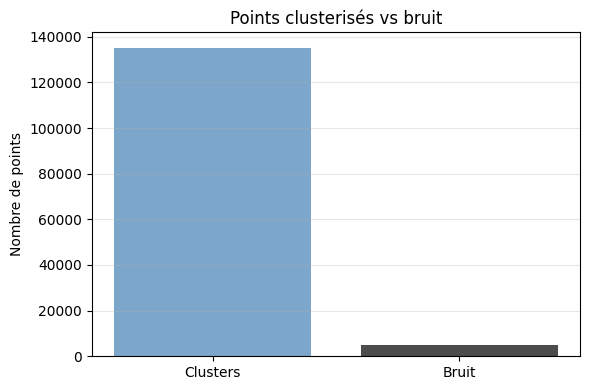

In [3]:
# ========================================
# ANALYSE DES CLUSTERS DBSCAN
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import os

# 🔹 CHEMIN DU FICHIER (modifie si besoin)
file_path = r"C:\Users\pc\Desktop\DM\results\dbscan_optimized_results.csv"

# 🔹 Charger les données
try:
    df = pd.read_csv(file_path)
    print(f"✓ Données chargées: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
except FileNotFoundError:
    print(f"❌ Fichier non trouvé: {file_path}")
    raise

# 🔹 Vérifier que la colonne 'cluster' existe
if 'cluster' not in df.columns:
    raise ValueError("La colonne 'cluster' est manquante dans le CSV.")

labels = df['cluster'].values
data = df.drop(columns=['cluster']).values  # Toutes les autres colonnes comme features

# ========================================
# Statistiques simples
# ========================================
n_points = len(labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("\n===== STATISTIQUES DBSCAN =====")
print(f"Nombre total de points   : {n_points:,}")
print(f"Nombre de clusters       : {n_clusters}")
print(f"Nombre de points de bruit: {n_noise:,} ({n_noise/n_points*100:.2f}%)")

# Distribution des clusters
counter = Counter(labels)
print("\nTop clusters:")
for label, count in sorted(counter.items(), key=lambda x: x[1], reverse=True)[:20]:
    if label != -1:
        print(f"Cluster {label}: {count:,} points ({count/n_points*100:.2f}%)")
if -1 in counter:
    print(f"Bruit: {counter[-1]:,} points ({counter[-1]/n_points*100:.2f}%)")


# ========================================
# Histogramme: points clusterisés vs bruit
# ========================================
n_clustered = (labels != -1).sum()
n_noise = (labels == -1).sum()

plt.figure(figsize=(6, 4))
plt.bar(['Clusters', 'Bruit'], [n_clustered, n_noise], color=['steelblue', 'black'], alpha=0.7)
plt.title("Points clusterisés vs bruit")
plt.ylabel("Nombre de points")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_noise_vs_clustered.png", dpi=150)
print("✓ Image sauvegardée: dbscan_noise_vs_clustered.png")
plt.show()


Shape du dataset: (140165, 16)

Premières lignes:
   latitude  longitude   TEB_log  CEC_CLAY  GYPSUM_log  TEXTURE_SOTER_encoded  \
0  36.74886    6.25409  2.995732      53.0    1.960095                    3.0   
1  35.87978    4.44782  3.806662      48.0    2.208274                    3.0   
2  35.70751    5.53337  3.806662      48.0    2.208274                    3.0   
3  32.27667    3.98647  3.806662      71.0    2.028148                    3.0   
4  32.40079    4.00642  3.806662      71.0    2.028148                    3.0   

   ORG_CARBON_log  LCCCODE_encoded  ELEC_COND_log  COARSE  \
0        2.205193              1.0       1.945910    11.0   
1        2.099734              3.0       2.079442     5.0   
2        2.099734             16.0       2.079442     5.0   
3        2.040571             18.0       2.197225     3.0   
4        2.040571              3.0       2.197225     3.0   

   TEXTURE_USDA_encoded  class      prec  elevation_scaled     tmean    trange  
0              

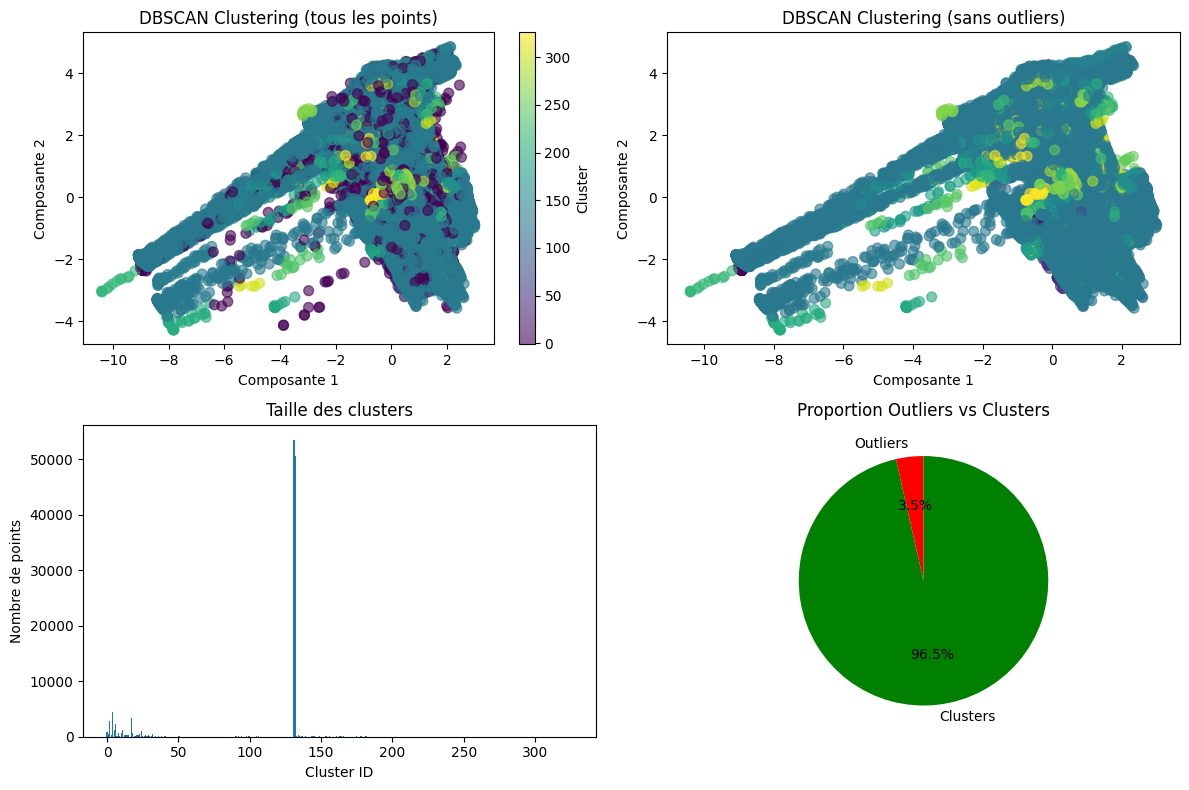

OSError: Cannot save file into a non-existent directory: '\content\drive\MyDrive'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
file_path = r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv"
df = pd.read_csv(file_path)

print("Shape du dataset:", df.shape)
print("\nPremières lignes:")
print(df.head())
print("\nTypes de colonnes:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNombre de colonnes numériques: {len(numeric_cols)}")

df_clean = df[numeric_cols].dropna()
print(f"Shape après nettoyage: {df_clean.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)


dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
clusters = dbscan.fit_predict(X_scaled)

# Ajouter les clusters au dataframe
df_clean['cluster'] = clusters

# Statistiques sur les clusters
print("\n" + "="*50)
print("RÉSULTATS DU CLUSTERING")
print("="*50)
unique_clusters = np.unique(clusters)
print(f"Nombre de clusters trouvés: {len(unique_clusters[unique_clusters != -1])}")
print(f"Nombre de points de bruit (outliers): {np.sum(clusters == -1)}")
print(f"Pourcentage d'outliers: {100 * np.sum(clusters == -1) / len(clusters):.2f}%")

print("\nDistribution des clusters:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"  Bruit (outliers): {count} points")
    else:
        print(f"  Cluster {cluster_id}: {count} points")

if X_scaled.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    print(f"\nVariance expliquée par les 2 premières composantes: {sum(pca.explained_variance_ratio_):.2%}")
else:
    X_pca = X_scaled

# Créer la visualisation
plt.figure(figsize=(12, 8))

# Plot 1: Tous les clusters
plt.subplot(2, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, 
                     cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title('DBSCAN Clustering (tous les points)')
plt.xlabel('Composante 1' if X_scaled.shape[1] > 2 else 'Feature 1')
plt.ylabel('Composante 2' if X_scaled.shape[1] > 2 else 'Feature 2')

# Plot 2: Sans les outliers
plt.subplot(2, 2, 2)
mask = clusters != -1
plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=clusters[mask], 
           cmap='viridis', alpha=0.6, s=50)
plt.title('DBSCAN Clustering (sans outliers)')
plt.xlabel('Composante 1' if X_scaled.shape[1] > 2 else 'Feature 1')
plt.ylabel('Composante 2' if X_scaled.shape[1] > 2 else 'Feature 2')

# Plot 3: Distribution des tailles de clusters
plt.subplot(2, 2, 3)
cluster_sizes = cluster_counts[cluster_counts.index != -1]
plt.bar(range(len(cluster_sizes)), cluster_sizes.values)
plt.xlabel('Cluster ID')
plt.ylabel('Nombre de points')
plt.title('Taille des clusters')

# Plot 4: Outliers vs clusters
plt.subplot(2, 2, 4)
labels = ['Outliers', 'Clusters']
sizes = [np.sum(clusters == -1), np.sum(clusters != -1)]
colors = ['red', 'green']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Proportion Outliers vs Clusters')

plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Sauvegarder les résultats
output_path = "/content/drive/MyDrive/merged_feature_final_clustered.csv"
df_clean.to_csv(output_path, index=False)
print(f"\nRésultats sauvegardés dans: {output_path}")

# Analyse des caractéristiques par cluster
print("\n" + "="*50)
print("STATISTIQUES PAR CLUSTER")
print("="*50)
for cluster_id in sorted(unique_clusters):
    if cluster_id != -1:
        cluster_data = df_clean[df_clean['cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_data)} points):")
        print(cluster_data.describe().loc[['mean', 'std']].head())